**Agenda**
- **PART 1 — Recap: What Trees Actually Learn**
- **PART 2 — Classification Trees**
- **PART 3 — Feature Selection in Trees**
- **PART 4 — Regression Trees**
- **PART 5 — Variance Reduction (Core Mathematics)**
- **PART 6 — Classification vs Regression Trees**
- **PART 7 — Bias–Variance Tradeoff**

Decision Tree - Classification & Regression

Tree structure terminology - Root node (top most - complete dataset - max impurity), decision (based on which your datais plit),
leaf (final node, based on which prediction is made), branches (connecting node)

classification
Recurisive splitting - on what basis the decision is plit --> max of purity --> impurity reduction --> Homogeous

classification
measures for splitting the tree
Gini impurity = 1 - sum pmax^2
Entropy = - sum p log2pmax

classification
decision tree will try to split a node based on what steps : -
1. calculate the impurity on whole data
2. Features, features numbers combinations, age/gender, age , age > 25
3. impurity on possible combinations, suppose one combination you spit the whole date on age > 25 , node1, node2
    --> calculate of impurity of node1, node2
    --> weighted avg of node1 and node2
    --> information gain ( differwnce of parent impurity - child impurity)
4. the one which gives you max information gain is the feature/feature value selected for splitting
5. Decision will stop building when - depth is maximum, leaf node is pure specially all leaf nodes,

classification & REGRESSION
Limitions
1. Overfitting - sensitive towards smaller changes

Algorithm - CART ( binary split ) , CHAID , I4 - non-binary split algo

stop overfitting in the model
Hyperparemters
1. Max depth
    --> max depth is shallow - depth 1 --> underfitting
    --> max depth is deep - depth 10 --> overfitting

optimium tree depth - gridsearch CV

# Classification Report Calculation

## Confusion Matrix

|                | **Predicted 0** | **Predicted 1** |
|----------------|----------------:|----------------:|
| **Actual 0**   | **2** | **1** |
| **Actual 1**   | **1** | **2** |

---

## Class 0

Here, **Class 0 is treated as Positive**:

|                | **Predicted 0** | **Predicted 1** |
|----------------|----------------:|----------------:|
| **Actual 0**   | **TP = 2** | **FN = 1** |
| **Actual 1**   | **FP = 1** | TN = 2 |

### Precision

$$
\text{Precision}_0 = \frac{\text{TP}}{\text{TP}+\text{FP}}
= \frac{2}{2+1}
= 0.67
$$

### Recall

$$
\text{Recall}_0 = \frac{\text{TP}}{\text{TP}+\text{FN}}
= \frac{2}{2+1}
= 0.67
$$

---

## Class 1

Now, **Class 1 is treated as Positive**:

|                | **Predicted 0** | **Predicted 1** |
|----------------|----------------:|----------------:|
| **Actual 0**   | TN = 2 | **FP = 1** |
| **Actual 1**   | **FN = 1** | **TP = 2** |

### Precision

$$
\text{Precision}_1 = \frac{\text{TP}}{\text{TP}+\text{FP}}
= \frac{2}{2+1}
= 0.67
$$

### Recall

$$
\text{Recall}_1 = \frac{\text{TP}}{\text{TP}+\text{FN}}
= \frac{2}{2+1}
= 0.67
$$

---

## How the Formula Evolves

The **formula never changes**:

$$
\text{Precision} = \frac{\text{TP}}{\text{TP}+\text{FP}}
$$

$$
\text{Recall} = \frac{\text{TP}}{\text{TP}+\text{FN}}
$$

Only the **TP, FP, and FN cells change** depending on which class we are treating as positive.

- **Class 0 →** top-left cell becomes **TP**
- **Class 1 →** bottom-right cell becomes **TP**

In [ ]:
# Sanjay - class imbalnce

# **PART 1 — Recap: What Trees Actually Learn**

**What is a Decision Tree?**

- A Decision Tree is a supervised learning algorithm that recursively partitions the feature space into smaller regions.

**Instead of learning a single equation like Linear Regression:**

- y = wx + b

**A tree learns:**

In [ ]:
print("""IF condition1
    THEN prediction A

ELSE IF condition2
    THEN prediction B

ELSE
    prediction C
""")

IF condition1
    THEN prediction A

ELSE IF condition2
    THEN prediction B

ELSE
    prediction C



**Intuition**

- Think of a decision tree as repeatedly asking questions:

In [ ]:
print("""
Age > 30 ?
        |
      Yes
        |
 Income > 50K ?
        |
      Yes
        |
   Buy Product""")


Age > 30 ?
        |
      Yes
        |
 Income > 50K ?
        |
      Yes
        |
   Buy Product


- Each question reduces uncertainty.

**Feature Space Partitioning**

- Suppose we have:

  - Feature 1 = Age
  - Feature 2 = Salary

**The tree creates boundaries:**
- Age < 25
- Age ≥ 25

- Salary < 50K
- Salary ≥ 50K


This divides the feature space into multiple regions.

**Visualization**


In [ ]:
print("""
Feature Space

+-----------+-----------+
| Region A  | Region B  |
|           |           |
+-----------+-----------+
| Region C  | Region D  |
|           |           |
+-----------+-----------+""")


Feature Space

+-----------+-----------+
| Region A  | Region B  |
|           |           |
+-----------+-----------+
| Region C  | Region D  |
|           |           |
+-----------+-----------+


- Each region receives a prediction.

**Recursive Splitting**

- Trees do not split once.

They repeatedly split regions.

In [ ]:
print("""
Root
 ├── Left
 │     ├── Left
 │     └── Right
 │
 └── Right
       ├── Left
       └── Right""")


Root
 ├── Left
 │     ├── Left
 │     └── Right
 │
 └── Right
       ├── Left
       └── Right


**This process is called:**

- Recursive Binary Partitioning

**Piecewise Constant Models**

- Decision trees produce:

  - Piecewise Constant Functions

**Meaning:**

- Different regions have different constant predictions.

**Example:**

In [ ]:
print("""Age < 20      → Prediction = 100

20 ≤ Age <40  → Prediction = 250

Age ≥40       → Prediction = 500""")

Age < 20      → Prediction = 100

20 ≤ Age <40  → Prediction = 250

Age ≥40       → Prediction = 500


**Classification vs Regression Objective**

- The tree structure remains identical.

Only the objective changes.
| Tree Type      | Goal            |
| -------------- | --------------- |
| Classification | Reduce impurity |
| Regression     | Reduce variance |


# **PART 2 — Classification Trees**

**Classification Tree Fundamentals**

- Classification trees are used when:

  - Target variable is categorical.

**Examples:**

In [ ]:
print("""
Spam / Not Spam

Fraud / Not Fraud

Buy / Not Buy

Disease / Healthy""")


Spam / Not Spam

Fraud / Not Fraud

Buy / Not Buy

Disease / Healthy


Here is a short and clear version in **Jupyter Notebook Markdown format**:

## **Goal**

A Decision Tree tries to create nodes where:

* Most samples belong to a single class.
* The node is as **pure as possible**.

---

## **Good Split**

### **Node A**

* Positive = 95
* Negative = 5

Most samples belong to the **Positive** class.

**Result:** The node is very pure.

---

## **Bad Split**

### **Node B**

* Positive = 50
* Negative = 50

The samples are equally distributed between both classes.

**Result:** The node is highly impure because the classes are mixed.

---

## **Prediction Mechanism**

After the tree finishes splitting, the final nodes are called **Leaf Nodes**.

* A leaf node contains the training samples that reach that node.
* The prediction is usually based on the **majority class**.

### **Example**

**Leaf Node:**

* Positive = 8
* Negative = 2

### **Prediction**

Since most samples are **Positive**:

**Prediction = Positive**

---

## **Class Probabilities**

Decision Trees can also provide the probability of each class.

### **Example**

**Leaf Node:**

* Positive = 8
* Negative = 2

Total samples:

$$
8 + 2 = 10
$$

Therefore:

$$
P(\text{Positive}) = \frac{8}{10} = 0.8
$$

$$
P(\text{Negative}) = \frac{2}{10} = 0.2
$$

### **Final Prediction**

* **Predicted Class:** Positive
* **P(Positive):** 0.8
* **P(Negative):** 0.2

> The Decision Tree predicts the **majority class**, while the class probabilities show the proportion of each class within the leaf node.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)

probabilities = tree.predict_proba([X[0]])

print(probabilities)

[[1. 0. 0.]]


## **Explanation**

* `predict_proba()` returns the **probability of each class** rather than directly returning only the predicted class.

For example:

```python
model.predict_proba(X_test)
```

The output for one data point might be:

```text
[0.8, 0.2]
```

Meaning:

* Probability of Class 0 = 0.8
* Probability of Class 1 = 0.2

The predicted class is usually the class with the **highest probability**.

---

## **Split Selection Process**

At every node, the Decision Tree evaluates:

* Feature 1
* Feature 2
* Feature 3
* ...

For numerical features, it also evaluates different possible **thresholds** for each feature.

For example:

```text
Age ≤ 25
Age ≤ 35
Age ≤ 45
```

The tree calculates how much each possible split improves the purity of the resulting child nodes.

---

## **Workflow**

### **Try Split A**

* Create child nodes
* Compute impurity
* Calculate impurity reduction

### **Try Split B**

* Create child nodes
* Compute impurity
* Calculate impurity reduction

### **Try Split C**

* Create child nodes
* Compute impurity
* Calculate impurity reduction

### **Choose the Best Split**

The tree selects the split that produces the **maximum reduction in impurity**.

---

## **Measuring Impurity**

Common impurity criteria include:

| Criterion               | Used For                                                       |
| ----------------------- | -------------------------------------------------------------- |
| Gini Index              | Most commonly used in Decision Trees                           |
| Entropy                 | Measures uncertainty and is used to calculate Information Gain |
| Log Loss                | Measures uncertainty based on predicted class probabilities    |
| Misclassification Error | Less commonly used for selecting splits                        |

> The Decision Tree tests different **features and split conditions**, measures the resulting impurity, and selects the split that creates the **purest child nodes**.


# **PART 3 — Feature Selection in Trees**

## **Trees Perform Feature Selection Automatically**

Decision Trees naturally select features that are useful for making predictions.

* No separate feature selection algorithm is required.
* Features are selected when they help create better splits.

This is called:

### **Embedded Feature Selection**

---

## **Why is it called Embedded Feature Selection?**

Feature selection happens automatically during the process of building the tree.

At each node, the tree:

* Evaluates different features
* Evaluates possible split conditions
* Selects the feature and condition that provide the best impurity reduction

Therefore:

* Useful features may appear in the tree.
* Features that do not improve the split may be ignored.

---

## **Example**

Suppose the dataset contains:

* Age
* Salary
* Gender
* Random_Noise

The Decision Tree may create splits such as:

```text id="tqtnqy"
Age > 30
    ↓
Salary > 50K
```

Here:

* `Age` is selected because it helps improve predictions.
* `Salary` is selected because it further improves predictions.
* `Random_Noise` may never appear because it does not provide a useful split.

---

## **Important Point**

If a feature is never used for splitting in a trained Decision Tree:

$$
\text{Feature Importance} = 0
$$

for that particular tree.

However, this does **not always mean the feature is completely useless**. Another tree, dataset, or hyperparameter setting may select it.

---

## **Feature Importance**

Feature importance measures:

> **How useful a feature was while building the Decision Tree.**

The importance of a feature is based on the amount of **impurity reduction** it produces through its splits.

---

## **Formula Intuition**

Conceptually:

```text id="o35abq"
Feature Importance
        =
Total Impurity Reduction
Generated by that Feature
```

A feature that creates many good splits and significantly reduces impurity will generally have higher importance.

---

## **Python Example**

```python id="4m0e2w"
# Get feature importance scores
feature_importance = model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": feature_importance
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df)
```

### **Interpretation**

* Higher importance → Feature contributed more to reducing impurity.
* Lower importance → Feature contributed less.
* Importance = 0 → Feature was not used for splitting in that tree.

---

## **Interview One-Liner**

> **Decision Trees perform embedded feature selection because they automatically select features that provide the best impurity reduction during splitting.**


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

tree = DecisionTreeClassifier()
tree.fit(X, y)

print(tree.feature_importances_)

[0.01333333 0.01333333 0.55072262 0.42261071]


## **Bias Toward High Cardinality Features**

Some features contain a large number of unique values. These are called **high-cardinality features**.

Examples include:

* `User_ID`
* `Transaction_ID`
* `Zip_Code`

A Decision Tree may sometimes prefer these features because they provide many possible split conditions.

---

## **Why Can This Be a Problem?**

Consider:

```text
User_ID
────────
User_001
User_002
User_003
User_004
...
```

A feature like `User_ID` may allow the tree to create very specific splits.

These splits can reduce impurity on the **training data**, but the model may simply be learning patterns specific to individual training samples.

### **Result**

* High training accuracy
* Poor performance on new data
* Increased risk of **overfitting**

---

## **Example**

Suppose a tree compares:

* `Age`
* `Income`
* `User_ID`

`User_ID` may create highly specific splits and appear useful during training.

However:

```text
User_ID = 10452
        ↓
Prediction = Positive
```

This rule may not make sense for a new user with a different ID.

Therefore, the split may not generalize well.

---

# **How Can We Mitigate This Problem?**

## **1. Remove Identifier Features**

Features such as:

* User ID
* Transaction ID
* Order ID
* Record ID

usually should not be used as model features.

```python
X = X.drop(
    columns=[
        "User_ID",
        "Transaction_ID"
    ]
)
```

This is often the **best solution** when the feature is simply an identifier.

---

### **Important Takeaway**

> A feature with many unique values may appear very useful because it can create highly specific splits, but this can cause the Decision Tree to overfit and perform poorly on unseen data.

### **Interview One-Liner**

> **Decision Trees can be biased toward high-cardinality features because these features provide many possible split points and may artificially reduce impurity, leading to overfitting. This can be mitigated by removing meaningless identifiers, controlling tree complexity, and validating performance on unseen data.**


# **PART 4 — Regression Trees**

## **What is a Regression Tree?**

A Regression Tree is used when the target variable is a **continuous numerical value**.

It predicts a number rather than a category or class.

### **Examples**

* House Price
* Revenue
* Temperature
* Product Demand

---

## **Key Difference**

### **Classification Tree**

Predicts a **class or category**.

Example:

```text
Disease
No Disease
```

### **Regression Tree**

Predicts a **continuous numerical value**.

Example:

```text
House Price = ₹50,00,000
Temperature = 32.5°C
```

---

## **Leaf Prediction**

In a Regression Tree, each leaf node contains training observations.

The prediction is typically the **mean of the target values** of the observations in that leaf.

### **Example**

Suppose a leaf contains the following target values:

* 100
* 120
* 130
* 150

The prediction for that leaf is:

$$
\text{Prediction}
=
\frac{100+120+130+150}{4}
$$

$$
= 125
$$

Therefore, any new observation that reaches this leaf will receive:

$$
\boxed{\text{Prediction} = 125}
$$

---

## **Piecewise Constant Function**

A Regression Tree does not usually produce a smooth continuous curve.

Instead, it divides the feature space into different regions.

Each region receives a fixed prediction value.

For example:

```text
Age ≤ 25        → Prediction = 100
25 < Age ≤ 40   → Prediction = 125
Age > 40        → Prediction = 150
```

Therefore, a Regression Tree produces **step-wise or piecewise constant predictions**.

---

## **Important Takeaway**

> **A Regression Tree splits the data into different regions and predicts the mean target value of the training observations within the final leaf node.**


In [ ]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

X = np.array([[1],[2],[3],[4],[5]])
y = np.array([10,20,30,40,50])

tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X, y)

print(tree.predict([[3.5]]))

[30.]


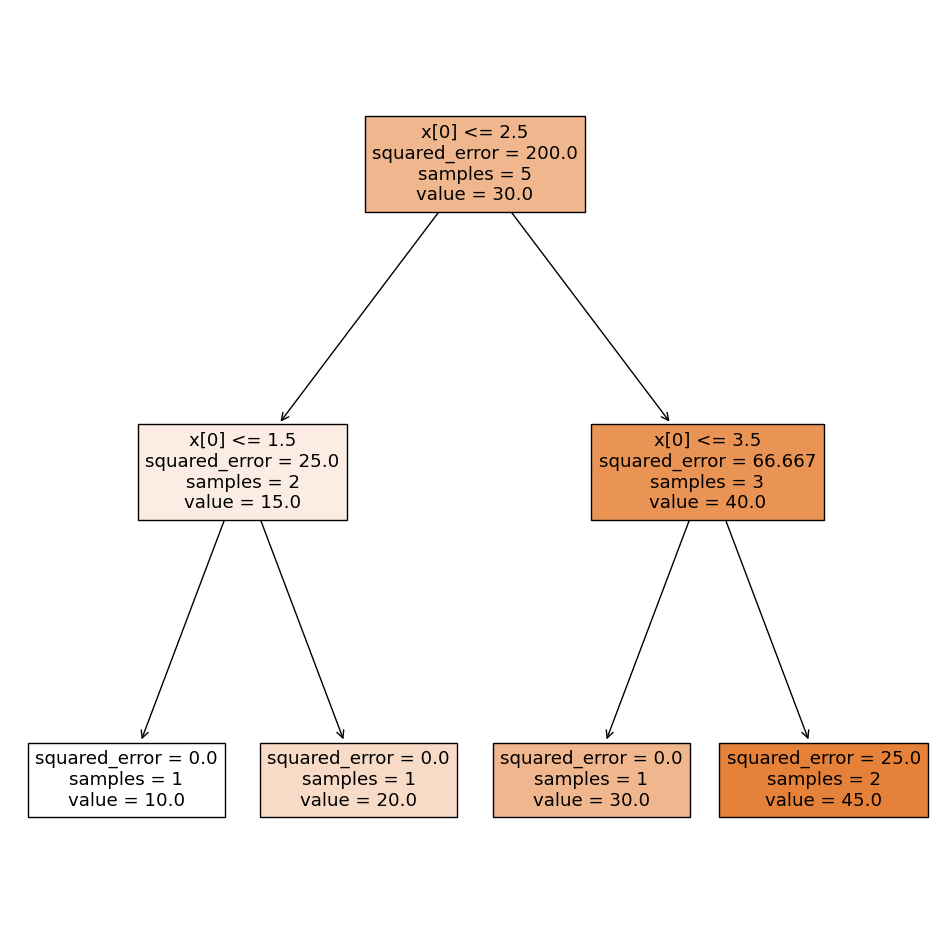

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))
plot_tree(tree, filled=True)
plt.show()

| **Criterion**        | **Formula / Measure**                                                        | **Minimum Impurity**                 | **Maximum Impurity** | **When to Use**                       | **Advantages**                                          | **Disadvantages**                           |                         |                                                    |
| -------------------- | ---------------------------------------------------------------------------- | ------------------------------------ | -------------------- | ------------------------------------- | ------------------------------------------------------- | ------------------------------------------- | ----------------------- | -------------------------------------------------- |
| **`squared_error`**  | $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \bar{y})^2$                           | `0` — all target values are the same | No fixed maximum     | General regression; default choice    | Simple, fast, strongly penalizes large errors           | Sensitive to outliers                       |                         |                                                    |
| **`friedman_mse`**   | MSE-based split improvement criterion proposed by Friedman                   | `0` — perfectly homogeneous node     | No fixed maximum     | Alternative MSE-based split criterion | May provide better split evaluation in some cases       | Less intuitive; less commonly used directly |                         |                                                    |
| **`absolute_error`** | $MAE = \frac{1}{n}\sum_{i=1}^{n}\left                                        \| y_i - \text{median}(y)\right         \| $                    | `0` — all target values are the same  | No fixed maximum                                        | Regression with significant outliers        | More robust to outliers | Slower; does not penalize large errors as strongly |
| **`poisson`**        | $D(y,\hat{y}) = 2\left[y\log\left(\frac{y}{\hat{y}}\right)-y+\hat{y}\right]$ (for one datapoint)| `0` — perfect fit                    | No fixed maximum     | Non-negative, count-like targets      | Suitable for count data and skewed non-negative targets | Cannot be used with negative target values  |                         |                                                    |

### **Quick Selection Guide**

| **Situation**                         | **Recommended Criterion** |
| ------------------------------------- | ------------------------- |
| General regression                    | `squared_error`           |
| Data contains strong outliers         | `absolute_error`          |
| Non-negative count data               | `poisson`                 |
| Alternative MSE-based split criterion | `friedman_mse`            |

# **PART 5 — Variance Reduction (Core Mathematics)**

## **Why Variance Matters**

A Regression Tree aims to create nodes where the target values are as **similar as possible**.

* Similar target values → **Low Variance**
* Very different target values → **High Variance**

---

## **Good Node vs Bad Node**

### **Good Node**

```text
100
101
102
103
```

The values are close together.

**Result:** Low variance.

### **Bad Node**

```text
10
500
900
1200
```

The values are very spread out.

**Result:** High variance.

---

## **Goal of a Regression Tree**

The tree selects splits that reduce the variation in the target values.

### **Split Criterion**

A good split should:

* Create child nodes with lower variance.
* Maximize **Variance Reduction**.
* Equivalently, minimize the **Mean Squared Error (MSE)** within the child nodes.

---

## **Numerical Example**

### **Parent Node**

Target values:

```text
[3, 4, 5, 6, 7]
```

Mean:

$$
\bar{y} = 5
$$

Variance:

$$
\text{Variance} =
\frac{(3-5)^2+(4-5)^2+(5-5)^2+(6-5)^2+(7-5)^2}{5}
= 2
$$

---

## **After the Split**

### **Left Child**

```text
[3, 4]
```

Mean:

$$
\frac{3+4}{2}=3.5
$$

Variance:

$$
\frac{(3-3.5)^2+(4-3.5)^2}{2}=0.25
$$

### **Right Child**

```text
[5, 6, 7]
```

Mean:

$$
\frac{5+6+7}{3}=6
$$

Variance:

$$
\frac{(5-6)^2+(6-6)^2+(7-6)^2}{3}
\approx 0.67
$$

---

## **Weighted Variance After Split**

The child node variances are weighted based on their number of samples:

$$
\text{Weighted Variance}
=
\frac{2}{5}(0.25)
+
\frac{3}{5}(0.67)
$$

$$
\approx 0.50
$$

---

## **Variance Reduction**

$$
\text{Variance Reduction}
=
\text{Parent Variance}
-
\text{Weighted Child Variance}
$$

$$
= 2 - 0.50
= 1.50
$$

### **Interpretation**

A larger variance reduction means the child nodes are more homogeneous.

> **Regression Trees evaluate different features and thresholds and select the split that produces the maximum reduction in variance.**


In [ ]:
import numpy as np

parent = np.array([3,4,5,6,7])
left = np.array([3,4])
right = np.array([5,6,7])

parent_var = np.var(parent)

weighted_child_var = (
    len(left)/len(parent) * np.var(left)
    +
    len(right)/len(parent) * np.var(right)
)

vr = parent_var - weighted_child_var

print(vr)

1.5


# **PART 6 — Classification vs Regression Trees**

**Comparison Table**
| Aspect     | Classification Tree | Regression Tree |
| ---------- | ------------------- | --------------- |
| Target     | Categorical         | Continuous      |
| Criterion  | Gini / Entropy      | Variance / MSE  |
| Output     | Class / Probability | Mean Value      |
| Objective  | Reduce Impurity     | Reduce Variance |
| Prediction | Label               | Numeric Value   |


# **PART 7 — Bias–Variance Tradeoff**

## **Shallow Trees**

A shallow Decision Tree has only a few levels.

### **Example**

* `max_depth = 1`

### **Characteristics**

* Simple structure
* Easier to interpret
* More stable
* May miss important patterns in the data

### **Result**

* **High Bias**
* **Low Variance**
* Risk of **Underfitting**

---

## **Deep Trees**

A deep Decision Tree has many levels and can create very specific rules.

### **Example**

* `max_depth = 25`

### **Characteristics**

* Learns complex patterns
* Can become very specific to the training data
* More sensitive to small changes in the data

### **Result**

* **Low Bias**
* **High Variance**
* Risk of **Overfitting**

---

## **Bias-Variance Trade-off**

| **Tree Type** | **Bias** | **Variance** | **Risk**     |
| ------------- | -------- | ------------ | ------------ |
| Shallow Tree  | High     | Low          | Underfitting |
| Deep Tree     | Low      | High         | Overfitting  |

---

## **Visualization**

```text
Simple Model                                      Complex Model

Shallow Tree                                      Deep Tree
High Bias                                         Low Bias
Low Variance                                      High Variance
Underfitting  ───────────────────────────────→    Overfitting
```

> **The goal is to find an appropriate tree depth that captures important patterns without memorizing the training data.**

